# H2O AutoML Baseline Experiment

This notebook evaluates H2O AutoML on the Breast Cancer Wisconsin dataset. The objective is to analyze automated model search, leaderboard generation, predictive performance, and enterprise-oriented AutoML workflow characteristics.

## H2O Initialization and AutoML Training

This section initializes the H2O cluster, converts the dataset into the H2O format, and launches the AutoML optimization process. Multiple machine learning models are automatically trained and evaluated using H2O AutoML.

In [1]:
#H2O AutoML classification experiment

import time
import h2o
from h2o.automl import H2OAutoML

from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Start H2O
h2o.init()

# 2. Load dataset
data = load_breast_cancer(as_frame=True)
df = data.frame

# 3. Make sure target is treated as a category, not a number
df["target"] = df["target"].astype("category")

# 4. Convert pandas dataframe to H2O dataframe
hf = h2o.H2OFrame(df)
hf["target"] = hf["target"].asfactor()

# 5. Split data into train and test sets
train, test = hf.split_frame(ratios=[0.7], seed=42)

# 6. Define features and target
x = [col for col in hf.columns if col != "target"]
y = "target"

# 7. Start timer
start = time.time()

# 8. Create AutoML model
aml = H2OAutoML(
    max_models=10,
    seed=42,
    verbosity="info"
)

# 9. Train AutoML
aml.train(x=x, y=y, training_frame=train)

# 10. Get best model
leader = aml.leader

# 11. Predict on test set
preds = leader.predict(test)

# 12. Convert predictions and test data back to pandas
pred_df = preds.as_data_frame()
test_df = test.as_data_frame()

# 13. Extract real values and predicted values
y_true = test_df["target"].astype(str)
y_pred = pred_df["predict"].astype(str)

# 14. Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label="1")
recall = recall_score(y_true, y_pred, pos_label="1")
f1 = f1_score(y_true, y_pred, pos_label="1")
cm = confusion_matrix(y_true, y_pred)

# 15. Stop timer
end = time.time()

# 16. Print results
print("Best model:", leader.model_id)
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

print("\nConfusion Matrix:")
print(cm)

print("\nExecution time:", round(end - start, 2), "seconds")

print("\nLeaderboard:")
print(aml.leaderboard.head(rows=10))

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 21.0.9+7-LTS-338, mixed mode, sharing)
  Starting server from C:\Users\souha\Downloads\Human Centered AutoML Thesis\h2o_env\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\souha\AppData\Local\Temp\tmp8ponotf8
  JVM stdout: C:\Users\souha\AppData\Local\Temp\tmp8ponotf8\h2o_souha_started_from_python.out
  JVM stderr: C:\Users\souha\AppData\Local\Temp\tmp8ponotf8\h2o_souha_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,Europe/Brussels
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,4 months and 14 days
H2O_cluster_name:,H2O_from_python_souha_uxxsky
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.913 Gb
H2O_cluster_total_cores:,12
H2O_cluster_allowed_cores:,12
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
12:49:48.474: Project: AutoML_1_20260726_124948
12:49:48.481: 5-fold cross-validation will be used.
12:49:48.483: Setting stopping tolerance adaptively based on the training frame: 0.05
12:49:48.483: Build control seed: 42
12:49:48.485: training frame: Frame key: AutoML_1_20260726_124948_training_py_3_sid_bce2    cols: 31    rows: 391  chunks: 1    size: 33689  checksum: 8300906661992651134
12:49:48.485: validation frame: NULL
12:49:48.485: leaderboard frame: NULL
12:49:48.485: blending frame: NULL
12:49:48.485: response column: target
12:49:48.485: fold column: null
12:49:48.485: weights column: null
12:49:48.501: AutoML: XGBoost is not available; skipping it.
12:49:48.505: Loading execution steps: [{XGBoost : [def_2 (1g, 10w), def_1 (2g, 10w), def_3 (3g, 10w), grid_1 (4g, 90w), lr_search (7g, 30w)]}, {GLM : [def_1 (1g, 10w)]}, {DRF : [def_1 (2g, 10w), XRT (3g, 10w)]}, {GB

c:\Users\souha\Downloads\Human Centered AutoML Thesis\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


## Confusion Matrix

The confusion matrix is used to inspect the prediction behavior of the best H2O AutoML model on the test dataset.

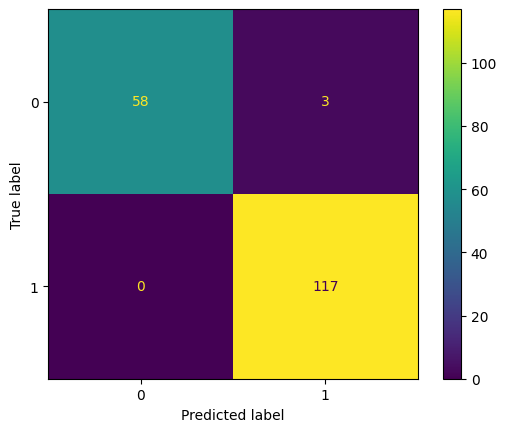

In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_true, y_pred)

plt.show()

In [3]:
import time

start = time.time()
preds = leader.predict(test)
end = time.time()

print("H2O inference time:", round(end - start, 4), "seconds")
print("Number of test samples:", test.nrows)
print("Average inference time per sample:", round((end - start) / test.nrows, 6), "seconds")

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
H2O inference time: 0.2465 seconds
Number of test samples: 178
Average inference time per sample: 0.001385 seconds


## H2O AutoML Results

H2O AutoML automatically trained and evaluated multiple machine learning models, including GLM, GBM, DRF, Deep Learning, and ensemble methods. The framework generated a leaderboard ranking models according to predictive performance.

Unlike TPOT, H2O focuses more on large-scale automated optimization and leaderboard generation than on editable pipeline transparency. The optimization process is highly automated and exposes detailed training logs and model-building activity.

In [4]:
# Export H2O model to the main Results folder

model_path = h2o.save_model(
    model=leader,
    path="../Results",
    force=True
)

print("H2O model exported successfully.")
print(model_path)

H2O model exported successfully.
C:\Users\souha\Downloads\Human Centered AutoML Thesis\Results\StackedEnsemble_BestOfFamily_1_AutoML_1_20260726_124948


In [5]:
from src.h2o_experiments import run_h2o_experiment
import h2o

h2o.init(
    nthreads=2,
    max_mem_size="6G"
)

test_result = run_h2o_experiment(
    dataset_name="breast_cancer",
    seed=42
)

test_result

Checking whether there is an H2O instance running at http://localhost:54321.

 connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,43 secs
H2O_cluster_timezone:,Europe/Brussels
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,4 months and 14 days
H2O_cluster_name:,H2O_from_python_souha_uxxsky
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.843 Gb
H2O_cluster_total_cores:,12
H2O_cluster_allowed_cores:,12
H2O_cluster_status:,"locked, healthy"



Running H2O: breast_cancer | seed 42
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |█
12:50:54.782: Project: AutoML_2_20260726_125054
12:50:54.782: Setting stopping tolerance adaptively based on the training frame: 0.04688072309384954
12:50:54.782: Build control seed: 42
12:50:54.782: training frame: Frame key: AutoML_2_20260726_125054_training_py_9_sid_9985    cols: 31    rows: 455  chunks: 1    size: 111919  checksum: 5432923230655197772
12:50:54.782: validation frame: NULL
12:50:54.782: leaderboard frame: NULL
12:50:54.782: blending frame: NULL
12:50:54.782: response column: target
12:50:54.782: fold column: null
12:50:54.782: weights column: null
12:50:54.782: AutoML: XGBoost is not available; skipping it.
12:50:54.782: Loading execution steps: [{XGBoost : [def_2 (1g, 10w), def_1 (2g, 10w), def_3 (3g, 10w), grid_1 (4g, 90w

c:\Users\souha\Downloads\Human Centered AutoML Thesis\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\souha\Downloads\Human Centered AutoML Thesis\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Best model: DeepLearning_grid_2_AutoML_2_20260726_125054_model_2
Macro F1: 0.9445
Runtime: 651.08 seconds


{'framework': 'H2O AutoML',
 'dataset': 'breast_cancer',
 'seed': 42,
 'accuracy': 0.9473684210526315,
 'precision_macro': 0.9382992327365729,
 'recall_macro': 0.9533730158730158,
 'f1_macro': 0.9444805194805195,
 'runtime_seconds': 651.082806300139,
 'best_model': 'DeepLearning_grid_2_AutoML_2_20260726_125054_model_2',
 'models_evaluated': 163,
 'model_path': 'C:\\Users\\souha\\Downloads\\Human Centered AutoML Thesis\\Results\\h2o\\breast_cancer\\seed_42\\DeepLearning_grid_2_AutoML_2_20260726_125054_model_2'}

In [1]:
from src.h2o_experiments import run_all_h2o_experiments

h2o_results = run_all_h2o_experiments()

h2o_results

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 21.0.9+7-LTS-338, mixed mode, sharing)
  Starting server from C:\Users\souha\Downloads\Human Centered AutoML Thesis\h2o_env\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\souha\AppData\Local\Temp\tmpmz5r3c94
  JVM stdout: C:\Users\souha\AppData\Local\Temp\tmpmz5r3c94\h2o_souha_started_from_python.out
  JVM stderr: C:\Users\souha\AppData\Local\Temp\tmpmz5r3c94\h2o_souha_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,Europe/Brussels
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,4 months and 14 days
H2O_cluster_name:,H2O_from_python_souha_tea63r
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,5.984 Gb
H2O_cluster_total_cores:,12
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"



Running H2O: breast_cancer | seed 42
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
20:49:56.547: Project: AutoML_1_20260726_204956
20:49:56.551: Setting stopping tolerance adaptively based on the training frame: 0.04688072309384954
20:49:56.551: Build control seed: 42
20:49:56.553: training frame: Frame key: AutoML_1_20260726_204956_training_py_1_sid_813b    cols: 31    rows: 455  chunks: 1    size: 111915  checksum: 5432923230655197772
20:49:56.553: validation frame: NULL
20:49:56.553: leaderboard frame: NULL
20:49:56.553: blending frame: NULL
20:49:56.553: response column: target
20:49:56.553: fold column: null
20:49:56.553: weights column: null
20:49:56.579: AutoML: XGBoost is not available; skipping it.
20:49:56.591: Loading execution steps: [{XGBoost : [def_2 (1g, 10w), def_1 (2g, 10w), def_3 (3g, 10w), grid_1 (4g, 90w)

c:\Users\souha\Downloads\Human Centered AutoML Thesis\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\souha\Downloads\Human Centered AutoML Thesis\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Best model: DeepLearning_grid_1_AutoML_1_20260726_204956_model_3
Macro F1: 0.9266
Runtime: 602.50 seconds

Running H2O: breast_cancer | seed 123
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
21:00:00.163: Project: AutoML_2_20260726_210000
21:00:00.163: Setting stopping tolerance adaptively based on the training frame: 0.04688072309384954
21:00:00.163: Build control seed: 123
21:00:00.163: training frame: Frame key: AutoML_2_20260726_210000_training_py_6_sid_813b    cols: 31    rows: 455  chunks: 1    size: 111919  checksum: -1882646659324030220
21:00:00.163: validation frame: NULL
21:00:00.163: leaderboard frame: NULL
21:00:00.163: blending frame: NULL
21:00:00.163: response column: target
21:00:00.163: fold column: null
21:00:00.163: weights column: null
21:00:00.163: AutoML: XGBoost is not available; skipping it.
21:00:00.1

...

c:\Users\souha\Downloads\Human Centered AutoML Thesis\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\souha\Downloads\Human Centered AutoML Thesis\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
22:09:53.475: Project: AutoML_9_20260726_220953
22:09:53.475: Setting stopping tolerance adaptively based on the training frame: 0.03090485136077065
22:09:53.475: Build control seed: 2026
22:09:53.475: training frame: Frame key: AutoML_9_20260726_220953_training_py_41_sid_813b    cols: 13    rows: 1047  chunks: 1    size: 18264  checksum: -7525648036292059649
22:09:53.475: validation frame: NULL
22:09:53.475: leaderboard frame: NULL
22:09:53.475: blending frame: NULL
22:09:53.475: response column: target
22:09:53.475: fold column: null
22:09:53.475: weights column: null
22:09:53.475: AutoML: XGBoost is not available; skipping it.
22:09:53.475: Loading execution steps: [{XGBoost : [def_2 (1g, 10w), def_1 (2g, 10w), def_3 (3g, 10w), grid_1 (4g, 90w), lr_search (6g, 30w)]}, {GLM : [d

c:\Users\souha\Downloads\Human Centered AutoML Thesis\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\souha\Downloads\Human Centered AutoML Thesis\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Best model: StackedEnsemble_AllModels_4_AutoML_9_20260726_220953
Macro F1: 0.7722
Runtime: 594.52 seconds
H2O session _sid_813b closed.


,framework,dataset,seed,accuracy,precision_macro,recall_macro,f1_macro,runtime_seconds,best_model,models_evaluated,model_path
0,H2O AutoML,breast_cancer,42,0.929825,0.919508,0.939484,0.926570,602.504012,DeepLearning_grid_1_AutoML_1_20260726_204956_m...,128,C:\Users\souha\Downloads\Human Centered AutoML...
1,H2O AutoML,breast_cancer,123,0.991228,0.988372,0.993056,0.990621,602.018388,StackedEnsemble_BestOfFamily_6_AutoML_2_202607...,116,C:\Users\souha\Downloads\Human Centered AutoML...
2,H2O AutoML,breast_cancer,2026,0.912281,0.902187,0.925595,0.908887,598.102286,GBM_3_AutoML_3_20260726_211003,62,C:\Users\souha\Downloads\Human Centered AutoML...
3,H2O AutoML,wine,42,0.944444,0.958333,0.933333,0.940741,601.744899,StackedEnsemble_BestOfFamily_3_AutoML_4_202607...,172,C:\Users\souha\Downloads\Human Centered AutoML...
4,H2O AutoML,wine,123,0.972222,0.974359,0.976190,0.974321,602.898330,GBM_grid_1_AutoML_5_20260726_213005_model_48,137,C:\Users\souha\Downloads\Human Centered AutoML...
5,H2O AutoML,wine,2026,0.972222,0.974359,0.976190,0.974321,601.619441,DRF_1_AutoML_6_20260726_214008,128,C:\Users\souha\Downloads\Human Centered AutoML...
6,H2O AutoML,titanic,42,0.824427,0.813603,0.815926,0.814710,590.980065,StackedEnsemble_BestOfFamily_6_AutoML_7_202607...,60,C:\Users\souha\Downloads\Human Centered AutoML...
7,H2O AutoML,titanic,123,0.770992,0.757546,0.761235,0.759191,590.059091,GBM_grid_1_AutoML_8_20260726_220002_model_7,68,C:\Users\souha\Downloads\Human Centered AutoML...
8,H2O AutoML,titanic,2026,0.778626,0.769539,0.782716,0.772201,594.518542,StackedEnsemble_AllModels_4_AutoML_9_20260726_...,56,C:\Users\souha\Downloads\Human Centered AutoML...
